## 📂 Dataset Loading and Preparation 🌿🧪

In this section, we will load and prepare the **Plant Leaf Disease Dataset** for training and evaluation using **PyTorch**. The dataset includes multiple classes such as healthy and diseased leaves from various crops. 🍅🍇🌾


In [1]:
from google.colab import drive
import os

drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/dataset.zip"
extract_dir = "/content/dataset"

if not os.path.exists(extract_dir):
  !unzip -q "{zip_path}" -d "{extract_dir}"
  print("Dataset unzipped successfully!")
else:
  print("Dataset already extracted.")


Mounted at /content/drive
Dataset unzipped successfully!


In [2]:
!pip install -q thop torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.9 MB/s eta 0:00:00


In [5]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

TRAIN_DIR = "/content/dataset/dataset/train"
TEST_DIR  = "/content/dataset/dataset/test"
DATA_DIR  = "/content/dataset/dataset"

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Loaded {len(train_dataset)} training images across {len(train_dataset.classes)} classes.")
print(f"Loaded {len(test_dataset)} testing images.")

Loaded 2720 training images across 3 classes.
Loaded 680 testing images.


🌱🧠 **HPDCNet** is a lightweight convolutional neural network that combines depthwise adaptive residuals, hybrid pooling, and conditional feature enhancement. Designed for efficient and robust visual recognition, it fuses multi-scale features with recalibrated attention for superior performance.
### 🔬 Potential Applications:

✅ Smart Farming  
✅ Mobile Disease Detection Apps  
✅ Precision Agriculture  
✅ Drone Crop Monitoring  


In [6]:
import os
import time
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchmetrics
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from thop import profile

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Block Definitions ---

class DepthwiseAdaptiveResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(DepthwiseAdaptiveResidualBlock, self).__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size=3, stride=stride, padding=1, groups=in_channels
        )
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.shortcut = (
        nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        if (in_channels != out_channels or stride != 1)
        else nn.Identity()
    )

    def forward(self, x):
        identity = self.shortcut(x)
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return F.relu(x + identity)


class ECABlock(nn.Module):
    def __init__(self, kernel_size=3):
        super(ECABlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=(kernel_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y)
        y = y.transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)


class MultiScaleFusionBlock(nn.Module):
    def __init__(self, in_channels):
        super(MultiScaleFusionBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.conv3 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels, in_channels, kernel_size=5, padding=2)

    def forward(self, x):
        x1 = self.conv1(x)
        x3 = self.conv3(x)
        x5 = self.conv5(x)
        return x1 + x3 + x5


class HybridPoolingLayer(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super(HybridPoolingLayer, self).__init__()
        self.max_pool = nn.MaxPool2d(kernel_size, stride)
        self.avg_pool = nn.AvgPool2d(kernel_size, stride)

    def forward(self, x):
        max_pooled = self.max_pool(x)
        avg_pooled = self.avg_pool(x)
        return (max_pooled + avg_pooled) / 2


class HPDCNet(nn.Module):
    def __init__(self, num_classes=10):
        super(HPDCNet, self).__init__()

        # Stage 1
        self.layer1 = DepthwiseAdaptiveResidualBlock(3, 16)
        self.attn1 = ECABlock()
        self.pool1 = HybridPoolingLayer()

        # Stage 2
        self.layer2 = DepthwiseAdaptiveResidualBlock(16, 32)
        self.attn2 = ECABlock()
        self.pool2 = HybridPoolingLayer()

        # Stage 3
        self.layer3 = DepthwiseAdaptiveResidualBlock(32, 64)
        self.fusion3 = MultiScaleFusionBlock(64)
        self.attn3 = ECABlock()
        self.pool3 = HybridPoolingLayer()

        # Stage 4
        self.layer4 = DepthwiseAdaptiveResidualBlock(64, 128)
        self.fusion4 = MultiScaleFusionBlock(128)
        self.attn4 = ECABlock()

        # Classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.attn1(x)
        x = self.pool1(x)

        x = self.layer2(x)
        x = self.attn2(x)
        x = self.pool2(x)

        x = self.layer3(x)
        x = self.fusion3(x)
        x = self.attn3(x)
        x = self.pool3(x)

        x = self.layer4(x)
        x = self.fusion4(x)
        x = self.attn4(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

### 🏋️ Model Training Procedure

The `HPDCNet` model was trained for 200 epochs using the Adam optimizer with a learning rate of `0.001` and CrossEntropyLoss.  
Training and validation were conducted on a multi-class classification task with 10 classes.

**Training Pipeline:**
- Device: GPU
- Data: Loaded via `train_loader` and `valid_loader`
- Metrics: Accuracy, Precision, Recall, and F1 Score (macro average using TorchMetrics)
- Best model checkpoint saved based on highest validation accuracy


In [9]:
# Instantiate Model and Setup Training Components
num_classes = len(train_dataset.classes)
model = HPDCNet(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Model Profiling
input_tensor = torch.randn(1, 3, 224, 224).to(device)
flops, params = profile(model, inputs=(input_tensor,))
print(f"FLOPs: {flops / 1e6:.2f} M, Params: {params / 1e6:.2f} M")

valid_loader = test_loader

train_losses, val_losses = [], []
train_accs, val_accs = [], []

num_epochs = 200
best_loss = float('inf')

for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels.data)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_accuracy_value = (correct_train.double() / total_train).item()

    # --- Validation Phase ---
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels.data)
            total_val += labels.size(0)

    valid_loss = val_running_loss / total_val
    valid_accuracy_value = (correct_val.double() / total_val).item()

    train_losses.append(train_loss)
    val_losses.append(valid_loss)
    train_accs.append(train_accuracy_value)
    val_accs.append(valid_accuracy_value)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy_value:.4f} | Val Loss: {valid_loss:.4f}, Val Acc: {valid_accuracy_value:.4f}")

    if valid_loss < best_loss:
        best_loss = valid_loss
        torch.save(model.state_dict(), "best_model.pth")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register count_avgpool() for <class 'torch.nn.modules.pooling.AvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 955.00 M, Params: 0.74 M
Epoch 1/200 - Train Loss: 0.8333, Train Acc: 0.6390 | Val Loss: 1.4069, Val Acc: 0.4676
Epoch 2/200 - Train Loss: 0.5969, Train Acc: 0.7438 | Val Loss: 0.8969, Val Acc: 0.5985
Epoch 3/200 - Train Loss: 0.5043, Train Acc: 0.7934 | Val Loss: 0.5614, Val Acc: 0.7735
Epoch 4/200 - Train Loss: 0.4715, Train Acc: 0.8103 | Val Loss: 0.9766, Val Acc: 0.5515
Epoch 5/200 - Train Loss: 0.4195, Train Acc

In [10]:
torch.save(model.state_dict(), "HPDCNet_best.pth")

### 🏋️ Model Testing


GPU (Tesla T4) Average Test Accuracy: 0.9235
GPU Average Test Precision: 0.9230
GPU Average Test Recall: 0.9246
GPU Average Test F1 Score: 0.9233
GPU Average Inference Time per Image: 6.968565 ms
GPU Frames per Second: 143.50


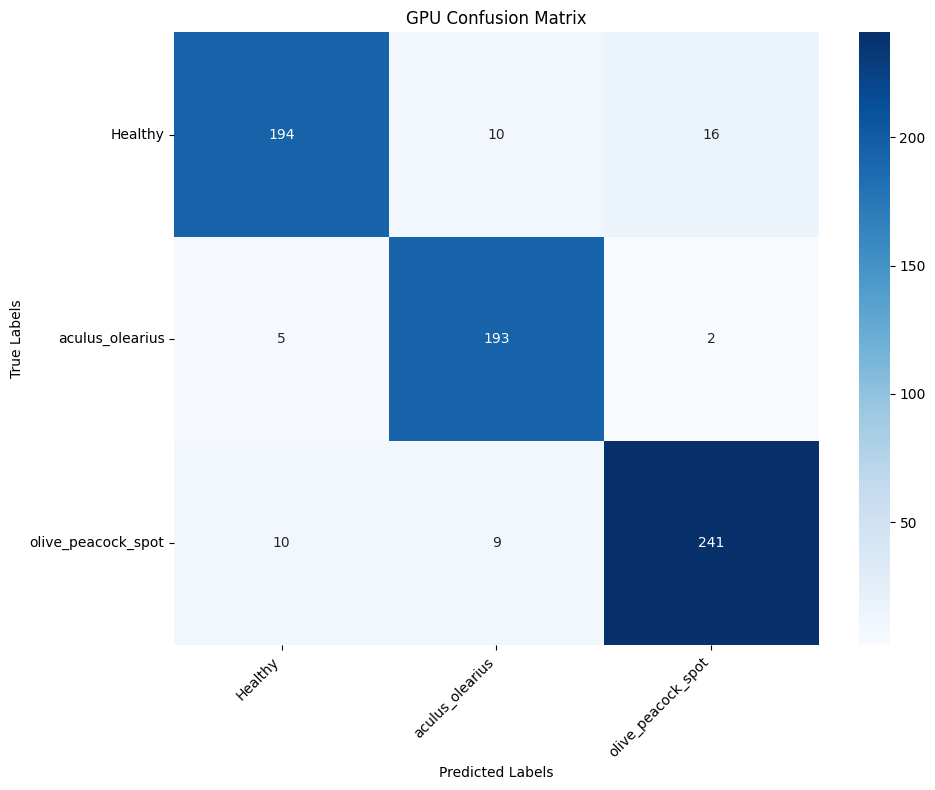

In [18]:
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torchmetrics
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset & DataLoader Setup
data_dir = DATA_DIR
valid_test_transforms = test_transforms

test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "test"), transform=valid_test_transforms
)
class_names = test_dataset.classes
num_classes = len(class_names)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load Model Checkpoint
model = HPDCNet(num_classes=num_classes).to(device)
model_path = "/content/best_model.pth"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device), strict=False)
model.eval()

# Metrics Setup
test_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(device)
test_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)
test_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)
test_f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)
test_confusion_matrix = torchmetrics.ConfusionMatrix(task="multiclass", num_classes=num_classes).to(device)

def perform_inference(device, num_runs=5):
    model.to(device)
    inference_times = []

    # Warm-up run for GPU timing accuracy
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            _ = model(inputs)
            break

    # Reset metrics before starting evaluation
    test_accuracy.reset()
    test_precision.reset()
    test_recall.reset()
    test_f1_score.reset()
    test_confusion_matrix.reset()

    # Benchmark run loop for precise inference timing
    for run in range(num_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        start_time = time.time()

        all_labels, all_predictions = [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)

                # Update metrics on the single clean pass (run 0)
                if run == 0:
                    test_accuracy.update(predicted, labels)
                    test_precision.update(predicted, labels)
                    test_recall.update(predicted, labels)
                    test_f1_score.update(predicted, labels)
                    test_confusion_matrix.update(predicted, labels)

                    all_labels.extend(labels.cpu().numpy())
                    all_predictions.extend(predicted.cpu().numpy())

        if device.type == "cuda":
            torch.cuda.synchronize()
        end_time = time.time()

        # Total time for all test images in milliseconds
        inference_times.append((end_time - start_time) * 1000)

    # Calculate average time per single image across runs
    avg_total_run_time_ms = np.mean(inference_times)
    avg_inference_time = avg_total_run_time_ms / len(test_loader.dataset)

    # Compute final metric scores
    avg_accuracy = test_accuracy.compute().item()
    avg_precision = test_precision.compute().item()
    avg_recall = test_recall.compute().item()
    avg_f1 = test_f1_score.compute().item()
    cm = test_confusion_matrix.compute().cpu().numpy()

    return (
        avg_accuracy,
        avg_precision,
        avg_recall,
        avg_f1,
        avg_inference_time,
        cm,
        all_labels,
        all_predictions,
    )

# Perform inference on GPU
(
    avg_accuracy_gpu,
    avg_precision_gpu,
    avg_recall_gpu,
    avg_f1_gpu,
    avg_inference_time_gpu,
    cm_gpu,
    labels_gpu,
    preds_gpu,
) = perform_inference(device)

fps_gpu = 1000 / avg_inference_time_gpu if avg_inference_time_gpu > 0 else 0
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

print(f"GPU ({device_name}) Average Test Accuracy: {avg_accuracy_gpu:.4f}")
print(f"GPU Average Test Precision: {avg_precision_gpu:.4f}")
print(f"GPU Average Test Recall: {avg_recall_gpu:.4f}")
print(f"GPU Average Test F1 Score: {avg_f1_gpu:.4f}")
print(f"GPU Average Inference Time per Image: {avg_inference_time_gpu:.6f} ms")
print(f"GPU Frames per Second: {fps_gpu:.2f}")

# Plot Confusion Matrix
def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_gpu, class_names, "GPU Confusion Matrix")

## 🧪 Visualizing Model Predictions on Sample Test Images

To better understand how the model performs on real data, we selected a set of 20 representative test images—two from each class (when available).

For each image, we performed forward inference and compared the **predicted label** against the **true label**:

- ✅ Correct predictions are shown with **green titles**
- ❌ Incorrect predictions are highlighted in **red**

The images are displayed in a grid layout for quick inspection. This visualization helps:

- Evaluate **class-wise performance**
- Identify **failure patterns**
- Visually inspect prediction **confidence and mistakes**


In [21]:
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torchmetrics
from torch.utils.data import DataLoader
from torchvision import datasets

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Dataset & DataLoader Setup
data_dir = DATA_DIR
test_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "test"), transform=test_transforms
)
class_names = test_dataset.classes
num_classes = len(class_names)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True
)

# 2. Instantiate and Verify Model Loading
model = HPDCNet(num_classes=num_classes).to(device)
model_path = "best_model.pth"

if not os.path.exists(model_path):
  raise FileNotFoundError(
      f"Checkpoint '{model_path}' not found! Check training output."
  )

model.load_state_dict(torch.load(model_path, map_location=device), strict=False)
model.eval()
print("Successfully loaded trained weights.")

# 3. Metrics Setup
test_accuracy = torchmetrics.Accuracy(
    task="multiclass", num_classes=num_classes
).to(device)
test_precision = torchmetrics.Precision(
    task="multiclass", num_classes=num_classes, average="macro"
).to(device)
test_recall = torchmetrics.Recall(
    task="multiclass", num_classes=num_classes, average="macro"
).to(device)
test_f1_score = torchmetrics.F1Score(
    task="multiclass", num_classes=num_classes, average="macro"
).to(device)
test_confusion_matrix = torchmetrics.ConfusionMatrix(
    task="multiclass", num_classes=num_classes
).to(device)


# 4. Corrected Inference & Metrics Computation
def evaluate_model(device):
  model.to(device)

  # Reset metrics
  test_accuracy.reset()
  test_precision.reset()
  test_recall.reset()
  test_f1_score.reset()
  test_confusion_matrix.reset()

  # Warm-up run for GPU timing
  with torch.no_grad():
    for inputs, _ in test_loader:
      _ = model(inputs.to(device))
      break

  # Benchmark latency across 5 runs
  inference_times = []
  for _ in range(5):
    if device.type == "cuda":
      torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
      for inputs, _ in test_loader:
        _ = model(inputs.to(device))

    if device.type == "cuda":
      torch.cuda.synchronize()
    inference_times.append((time.time() - start_time) * 1000)

  # Single evaluation pass for metrics
  with torch.no_grad():
    for inputs, labels in test_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)

      # Pass raw logits directly to torchmetrics
      test_accuracy.update(outputs, labels)
      test_precision.update(outputs, labels)
      test_recall.update(outputs, labels)
      test_f1_score.update(outputs, labels)
      test_confusion_matrix.update(outputs, labels)

  avg_inf_time = np.mean(inference_times) / len(test_loader.dataset)
  return (
      test_accuracy.compute().item(),
      test_precision.compute().item(),
      test_recall.compute().item(),
      test_f1_score.compute().item(),
      avg_inf_time,
      test_confusion_matrix.compute().cpu().numpy(),
  )


acc, prec, rec, f1, inf_time, cm = evaluate_model(device)
fps = 1000 / inf_time if inf_time > 0 else 0

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")
print(f"Test F1 Score:  {f1:.4f}")
print(f"Inference Time: {inf_time:.6f} ms/image")
print(f"FPS:            {fps:.2f}")


Successfully loaded trained weights.
Test Accuracy:  0.9235
Test Precision: 0.9230
Test Recall:    0.9246
Test F1 Score:  0.9233
Inference Time: 5.945006 ms/image
FPS:            168.21


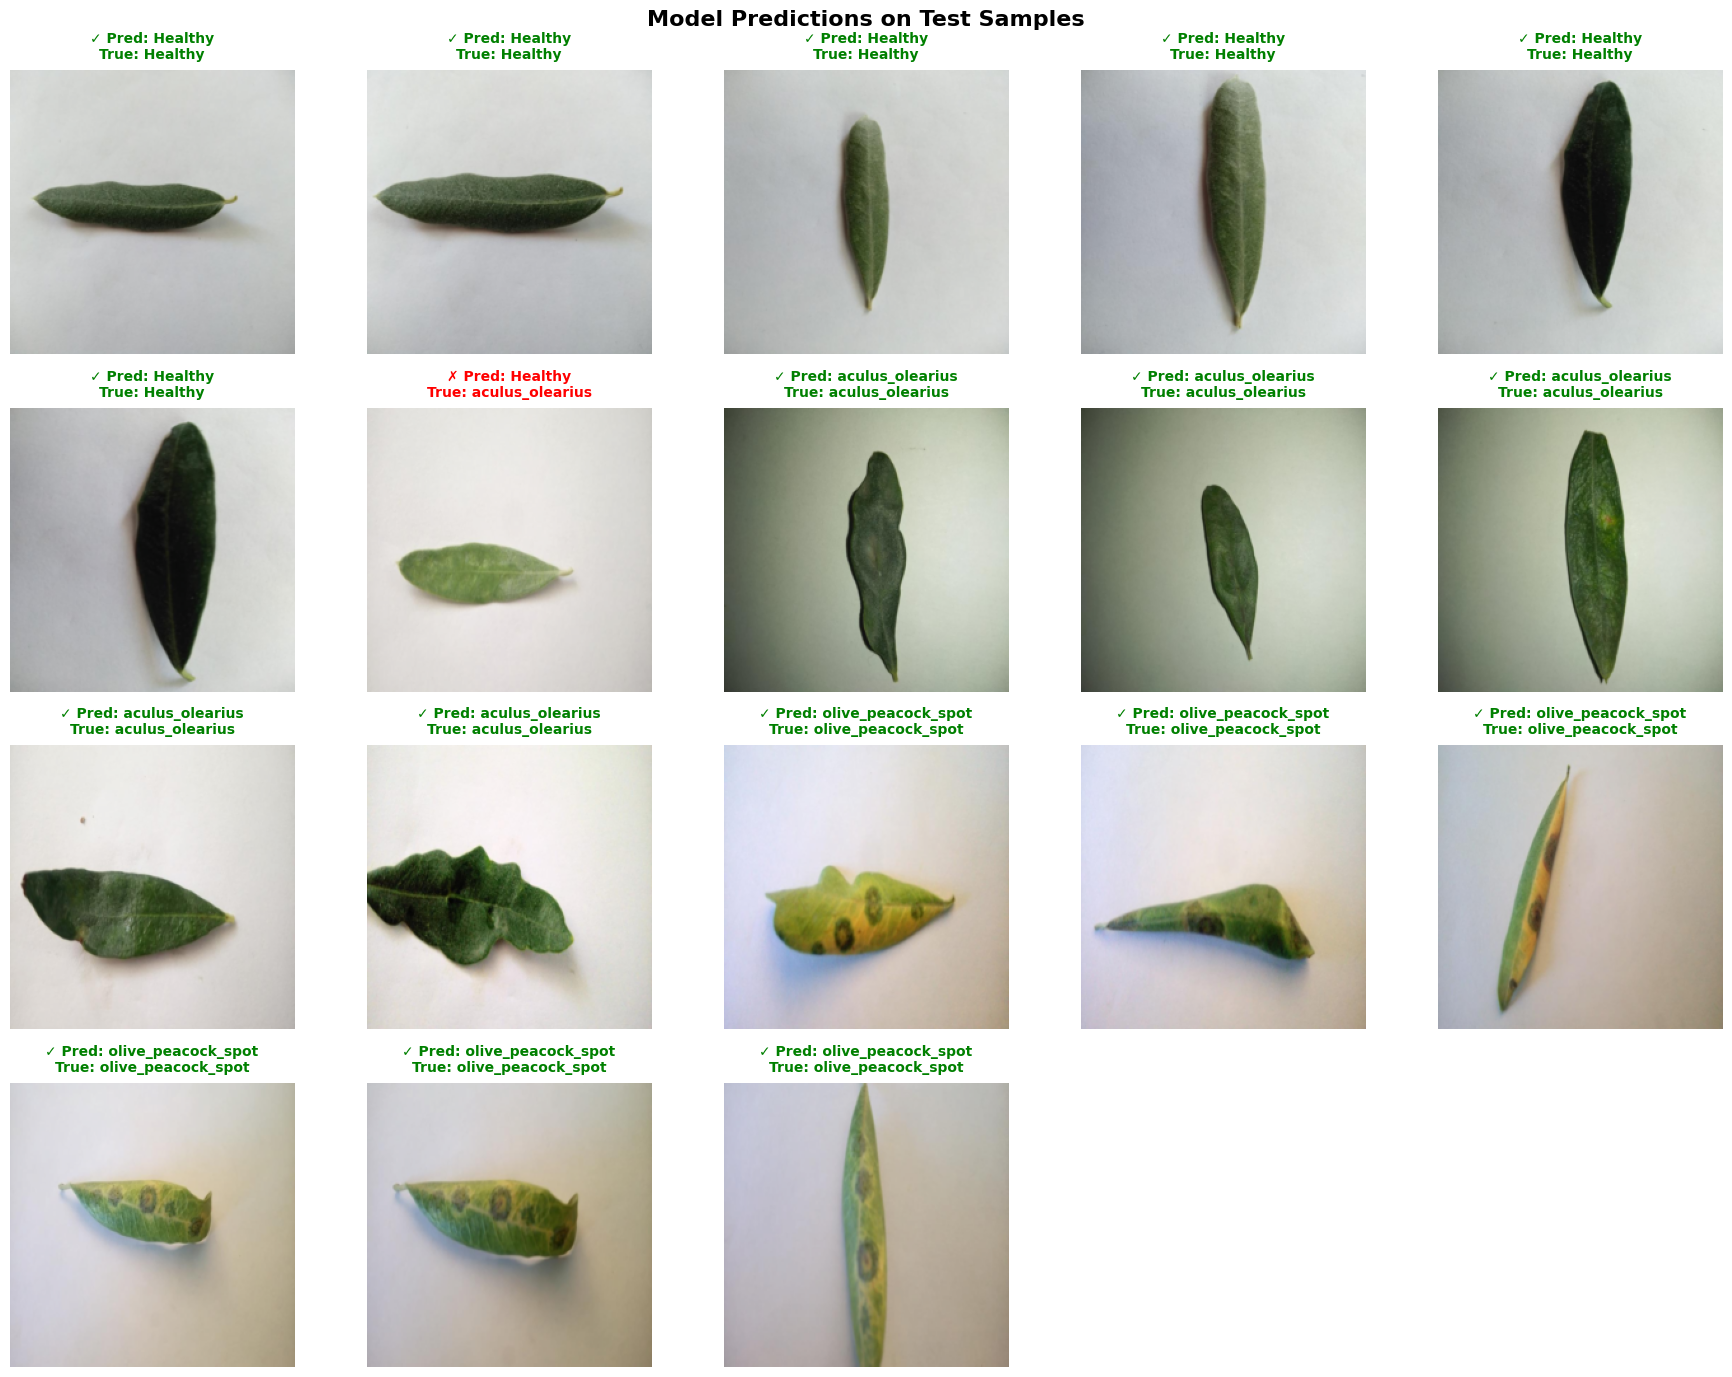

In [25]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Denormalization helper to display PyTorch tensors as original RGB images
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])


def denormalize(tensor):
  image = tensor.cpu().numpy().transpose((1, 2, 0))
  image = std * image + mean
  return np.clip(image, 0, 1)


# 2. Collect 2 sample images per class from test_dataset
samples_per_class = 6
selected_indices = []
class_counts = {i: 0 for i in range(num_classes)}

# Iterate through dataset to grab up to 2 samples per class
for idx in range(len(test_dataset)):
  _, label = test_dataset[idx]
  if class_counts[label] < samples_per_class:
    selected_indices.append(idx)
    class_counts[label] += 1
  if all(count == samples_per_class for count in class_counts.values()):
    break

# 3. Predict and plot in a 4x5 Grid
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()

model.eval()
with torch.no_grad():
  for i, idx in enumerate(selected_indices):
    image, label = test_dataset[idx]

    # Model Inference
    input_tensor = image.unsqueeze(0).to(device)
    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()

    true_name = class_names[label]
    pred_name = class_names[pred_class]

    # Format visual output
    img_display = denormalize(image)
    axes[i].imshow(img_display)
    axes[i].axis("off")

    is_correct = pred_class == label
    color = "green" if is_correct else "red"
    symbol = "✓" if is_correct else "✗"

    axes[i].set_title(
        f"{symbol} Pred: {pred_name}\nTrue: {true_name}",
        color=color,
        fontsize=10,
        fontweight="bold",
        pad=8,
    )

# Hide unused grid slots if total images < 20
for j in range(len(selected_indices), len(axes)):
  fig.delaxes(axes[j])

plt.suptitle("Model Predictions on Test Samples", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()